# [LAB 07] 8. 이원분산분석
## #연습문제

In [16]:
from hossam import load_data
from helpers import *

#### 문제 1. 분산분석을 하여 효소 함량에 따라 토마토 모종 성장에 차이가 나는지 검정하라

In [17]:
df1 = load_data('tomato')
df1.head()

📚 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에 어떤 영향을 주는지에 대한 실험 결과 (출처: 방송통신대학교 통계학 개론)


,효소함량,모종성장
0,0,9.500
1,0,10.000
2,0,10.700
3,0,9.000
4,0,12.400


In [18]:
my_stats.anova_oneway(df1, y='모종성장', between='효소함량')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,효소함량,2,87,81.094,0.000,0.651,Large


- 인사이트
    - 가정확인 : anova_oneway함수가 정규성과 등분산성 검정을 수행한 뒤 test를 anova로 출력하였다. 이는 등분산성 가정이 충족되어 ANOVA가 자동 선택되었음을 의미한다.
    - 검정결과 : F(2, 87)=81.094, p=0.000으로 유의수준 0.05보다 작다. 따라서 "효소 함량이 증가 여부가 토마토 모종 포기 성장에 영향을 주지 않는다"는 귀무가설을 기각한다. 즉, 효소 성분의 비료가 효소 함량 증가함에 따라 토마토 모종 포기의 성장에는 유의한 차이가 있다.
    - 효과 크기 : 부분 에타제곱(np2) = 0.651으로 0.14 이상에 해당하여 큰 효과로 해석된다. 효소 함량이 모종 성장 분산의 약 65%를 설명한다.
    - 결론 : 효소 성분의 비료 내 효소 함량 증가는 토마토 모종 성장에 유의하고 큰 영향을 미친다. 다만 분산분석은 어느 집단들 사이에 차이가 있는지 알려주지 않으므로 구체적인 집단 쌍 차이를 확인하려면 사후검정이 필요하다.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 100: Custom statistical test, P_val:7.229e-10
100 vs. 1000: Custom statistical test, P_val:9.517e-07
0 vs. 1000: Custom statistical test, P_val:2.220e-15


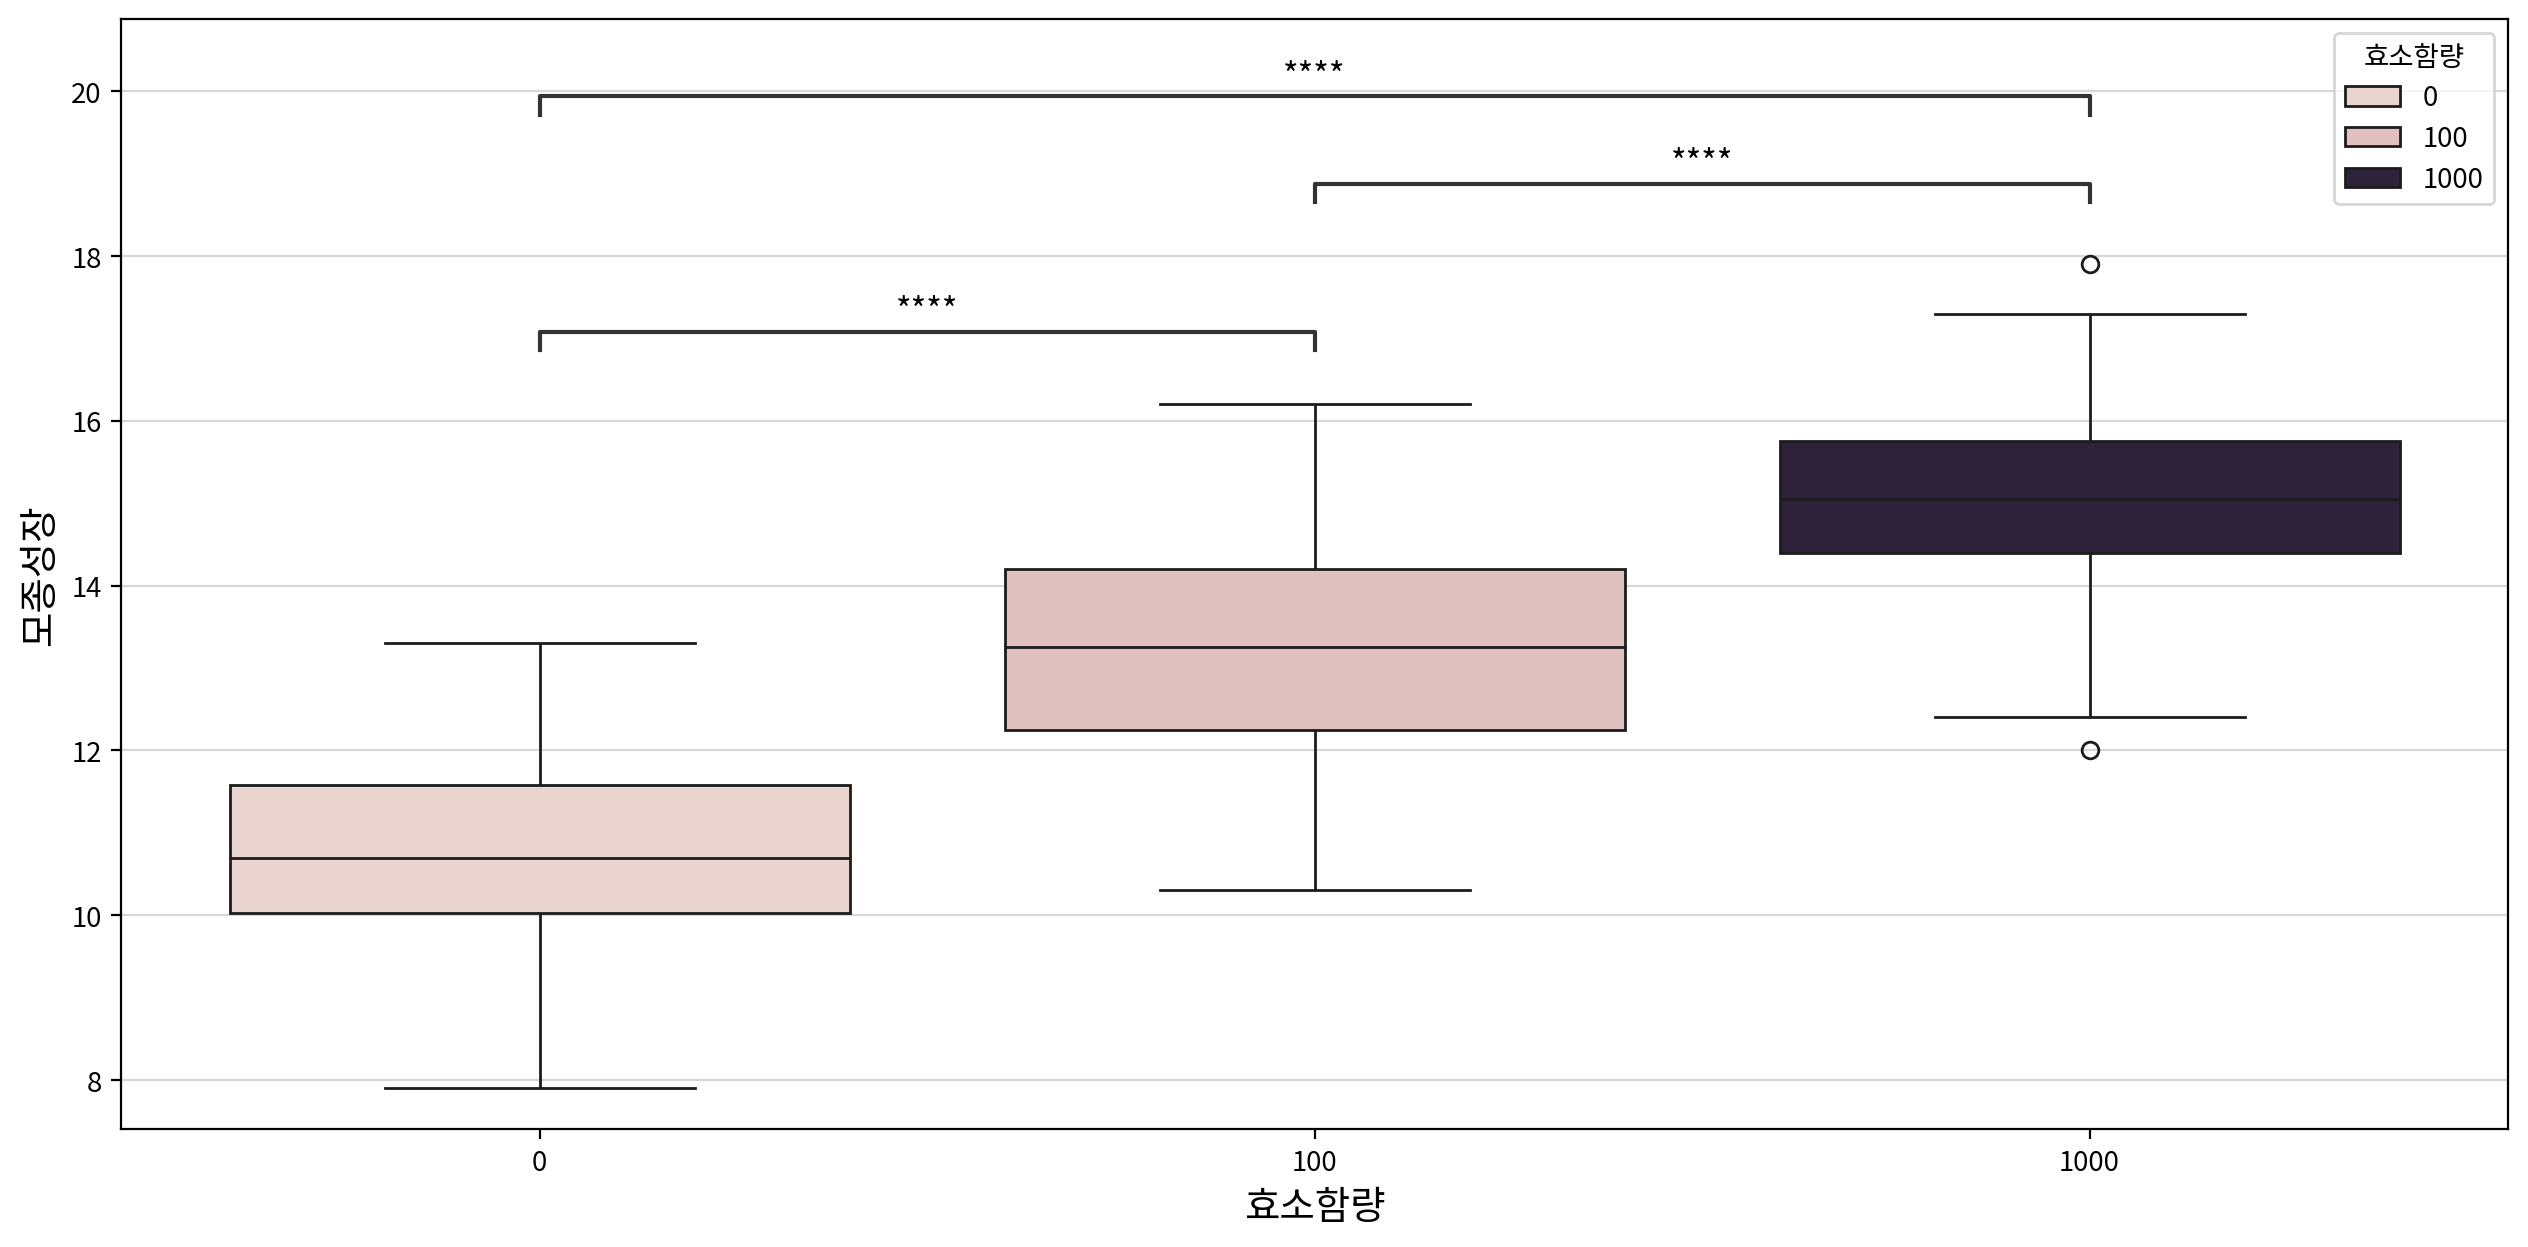

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,0,100,10.753,13.180,-2.427,0.339,-7.162,0.000,-1.868,True,Large
1,Tukey HSD,0,1000,10.753,15.057,-4.303,0.339,-12.701,0.000,-3.316,True,Large
2,Tukey HSD,100,1000,13.180,15.057,-1.877,0.339,-5.539,0.000,-1.351,True,Large


In [19]:
my_stats.posthoc_oneway(df1, y='모종성장', between='효소함량')

- 사후검정 결과에 대한 인사이트
    - 가정확인 : 결과표의 test가 Tukey HSD로 출력되었으므로 등분산성 가정이 충족됨
    - 집단별 평균 성장 : 효소함량 1000(15.057) > 100(13.180) > 0(10.753) 순이다.
    - 구체적 차이 : 3개 쌍이 모두 p=0.000으로 유의하여, 모든 비료가 효소 함량에 따른 토마토 모종 포기의 성장에 차이가 있다.
    - 결론 : 효소 함량에 따른 토마토 모종 포기의 성장 차이는 모든 비료에서 서로 통계적으로 유의하게 다르며, 특히 효소 함량이 1000인 비료에서 가장 높고 효소 함량이 0인 비료에서 가장 낮다. 

#### 문제 2. 사용된 독극물 종류와 치료 유형에 유의미한 차이가 있는지 분석하라

In [20]:
df2 = load_data('poisons')
df2.head()

📚 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)


,time,poison,treat
0,3.800,P1,T1
1,2.700,P1,T1
2,1.700,P1,T1
3,2.200,P1,T1
4,0.700,P1,T1


In [21]:
aov_helper = my_stats.anova_twoway(df2, y='time', between=['poison', 'treat'])
aov_helper.round(4)

,test,Source,SS,DF,MS,F,p_unc,np2,effect_size,significant
0,two-way ANOVA,poison,148.976,2,74.488,74.722,0.000,0.300,Large,True
1,two-way ANOVA,treat,131.261,3,43.754,43.891,0.000,0.275,Large,True
2,two-way ANOVA,poison * treat,81.382,6,13.564,13.606,0.000,0.190,Large,True
3,two-way ANOVA,Residual,346.910,348,0.997,NaN,NaN,NaN,-,False


In [22]:
aov_helper = my_stats.posthoc_twoway(df2, y='time', between=['poison', 'treat'])
aov_helper.round(4)

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,"P1, T1","P1, T2",1.980,2.670,-0.690,0.258,-2.677,0.242,-0.649,False,Medium
1,Tukey HSD,"P1, T1","P1, T3",1.980,2.370,-0.390,0.258,-1.513,0.936,-0.402,False,Small
2,Tukey HSD,"P1, T1","P1, T4",1.980,2.280,-0.300,0.258,-1.164,0.991,-0.328,False,Small
3,Tukey HSD,"P1, T1","P2, T1",1.980,3.070,-1.090,0.258,-4.228,0.002,-1.056,True,Large
4,Tukey HSD,"P1, T1","P2, T2",1.980,3.433,-1.453,0.258,-5.638,0.000,-1.480,True,Large
5,Tukey HSD,"P1, T1","P2, T3",1.980,4.143,-2.163,0.258,-8.392,0.000,-2.203,True,Large
6,Tukey HSD,"P1, T1","P2, T4",1.980,4.537,-2.557,0.258,-9.918,0.000,-2.569,True,Large
7,Tukey HSD,"P1, T1","P3, T1",1.980,2.040,-0.060,0.258,-0.233,1.000,-0.057,False,Negligible
8,Tukey HSD,"P1, T1","P3, T2",1.980,3.123,-1.143,0.258,-4.435,0.001,-1.110,True,Large
9,Tukey HSD,"P1, T1","P3, T3",1.980,3.750,-1.770,0.258,-6.866,0.000,-1.583,True,Large


- 이원분산분석 결과에 대한 인사이트
    - 등분산성 가정이 충족되어 일반 이원분산분석(two-way ANOVA)으로 분석하였다.
    - 독극물 종류(poison) 주효과는 유의하다(p < 0.001, np2=0.300, Large). 독극물 종류에 따라 동물의 생존시간에 유의미한 차이가 있다.
    - 치료 유형(treat) 주효과도 유의하다(p < 0.001, np2=0.275, Large). 치료 유형에 따라 동물의 생존시간에 유의미한 차이가 있다.
    - 상호작용효과(poison × treat)도 유의하다(p < 0.001, np2=0.190, Large). 독극물
     종류가 생존시간에 미치는 효과가 치료 유형에 따라 달라진다. 즉 어떤 독극물과 치료를 조합하느냐에 따라 생존시간이 달라진다고 해석할 수 있다.
    - 결론: 동물의 생존시간(time)은 독극물 종류와 치료 유형 각각에 의해 강하게 영향을 받으며, 두 요인의 조합에 따른 상호작용 효과도 통계적으로 유의하게 확인되었다.

#### 문제 3. 두가지 교육방법에 대한 국어와 영어의 효과가 서로 다르다고 할 수 있는지 검정하라.

In [23]:
df3 = load_data('edu')
df3.head()

📚 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)


,교육방법,국어,영어
0,1,65,82
1,1,87,79
2,1,73,85
3,1,79,60
4,1,81,65


In [24]:
df3_melt = df3.melt(id_vars='교육방법', value_vars=['국어', '영어'], var_name='과목', value_name='점수')
df3_melt.head()

,교육방법,과목,점수
0,1,국어,65
1,1,국어,87
2,1,국어,73
3,1,국어,79
4,1,국어,81


In [25]:
my_stats.anova_twoway(df3_melt, y='점수', between=['교육방법', '과목'])

,test,Source,SS,DF,MS,F,p_unc,np2,effect_size,significant
0,two-way ANOVA,교육방법,355.114,1,355.114,3.846,0.057,0.088,Medium,False
1,two-way ANOVA,과목,0.205,1,0.205,0.002,0.963,0.000,Negligible,False
2,two-way ANOVA,교육방법 * 과목,14.205,1,14.205,0.154,0.697,0.004,Negligible,False
3,two-way ANOVA,Residual,3693.455,40,92.336,NaN,NaN,NaN,-,False


- 이원분산분석 결과에 대한 인사이트
    - 등분산성 가정이 충족되어 일반 이원분산분석(two-way ANOVA)으로 분석하였다.
    - 모든 항목에서 유의하지 않다(p>0.05)
    - 교육방법의 효과는 0.088로 중간정도 이고 그 외의 과목과 교육방법*과목의 경우에는 효과가 없다.
    - 즉 두 교육방법의 효과가 국어와 영어에서 서로 다르다고 볼 통계적 근거는 없다.